# Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving loan_approval_dataset.json.zip to loan_approval_dataset.json.zip


In [4]:
import zipfile
import os

zip_path = "loan_approval_dataset.json.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("loan_data")

os.listdir("loan_data")

['loan_approval_dataset.json']

In [5]:
import pandas as pd
import os

file_path = "loan_data/loan_approval_dataset.json"  # adjust if filename is different

df = pd.read_json(file_path)

df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


# Explore Data

In [6]:
print(df.shape)

df.info()

df.describe()

(252000, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 26.9+ MB


,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,252000.000000,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,126000.500000,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,72746.278255,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,63000.750000,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,126000.500000,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,189000.250000,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,252000.000000,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


Check Target Variable

In [7]:
df["Risk_Flag"].value_counts()

,count
Risk_Flag,
0,221004
1,30996


# Data Cleaning

Check for missing values

In [8]:
df.isnull().sum()

,0
Id,0
Income,0
Age,0
Experience,0
Married/Single,0
House_Ownership,0
Car_Ownership,0
Profession,0
CITY,0
STATE,0


Check for duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:

# 3. Remove ID
df = df.drop("Id", axis=1)

# 4. Check categories
df["Married/Single"].value_counts()

# 5. Check numerical ranges
df.describe()

,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


# Class Imbalance

In [11]:
df["Risk_Flag"].value_counts(normalize=True)

,proportion
Risk_Flag,
0,0.877
1,0.123


# Train-Test Split

Split the data so that 80% is used to train and then 20% is used to test it.

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop("Risk_Flag", axis=1)
y = df["Risk_Flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(201600, 11)
(50400, 11)
(201600,)
(50400,)


In [14]:
print(y_train.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))

Risk_Flag
0    0.876999
1    0.123001
Name: proportion, dtype: float64
Risk_Flag
0    0.877004
1    0.122996
Name: proportion, dtype: float64


# Encode the categorical variables


convert the text into numbers

Check which columns are categorical

In [15]:
X_train.select_dtypes(include="object").columns

Index(['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession',
       'CITY', 'STATE'],
      dtype='object')

encode

In [16]:
X = pd.get_dummies(X, drop_first=True)

# Train model

Logistic Regression

Model is training

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical features (based on X_train.select_dtypes(include="object").columns output)
categorical_features = ['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE']

# Create a ColumnTransformer for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical columns as they are
)

# Fit the preprocessor on X_train and transform both X_train and X_test
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

lr = LogisticRegression(max_iter=1000)

# Fit the model with the encoded data
lr.fit(X_train_encoded, y_train)

LogisticRegression(max_iter=1000)

Model is being tested on the 20% of data it can't see (includes the newly converted numerical columns)

In [18]:
lr_pred = lr.predict(X_test_encoded)

Evaluate the Model

See how well Logistic Regression Performed

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     44201
           1       0.00      0.00      0.00      6199

    accuracy                           0.88     50400
   macro avg       0.44      0.50      0.47     50400
weighted avg       0.77      0.88      0.82     50400



Visualisation

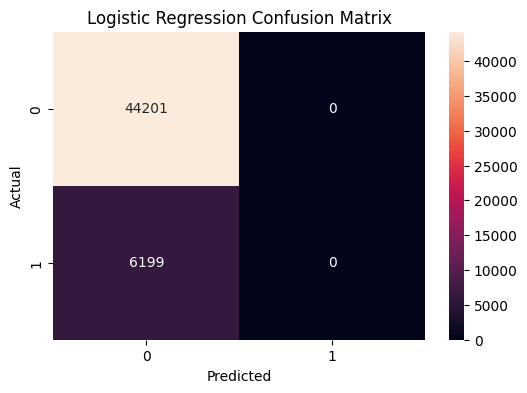

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Retrain model for better accuracy

In [21]:
import numpy as np

np.unique(lr_pred, return_counts=True)

(array([0]), array([50400]))

Fix Class weights

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train_encoded, y_train)

lr_pred = lr.predict(X_test_encoded)

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.88      0.69      0.77     44201
           1       0.12      0.31      0.18      6199

    accuracy                           0.65     50400
   macro avg       0.50      0.50      0.48     50400
weighted avg       0.78      0.65      0.70     50400



Visualisation

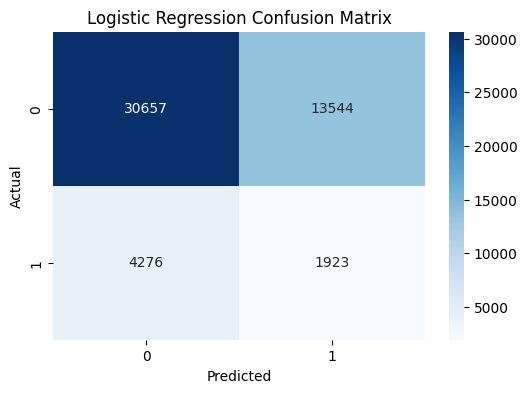

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Result

After introducing class weighting, the Logistic Regression model showed some improvement and was able to identify a portion of the high-risk applicants. However, performance remained relatively poor. While the model achieved an overall accuracy of 65%, accuracy alone is not a reliable metric due to the class imbalance in the dataset. The model achieved a recall of 31% for high-risk applicants, meaning that it still failed to identify the majority of risky individuals. Furthermore, the low precision score for the high-risk class indicates that many applicants predicted as high risk were actually low risk.

# Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train_encoded, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Make Predictions

In [25]:
rf_pred = rf.predict(X_test_encoded)

Evaluate

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      0.91      0.94     44201
           1       0.55      0.76      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400



Visualisation

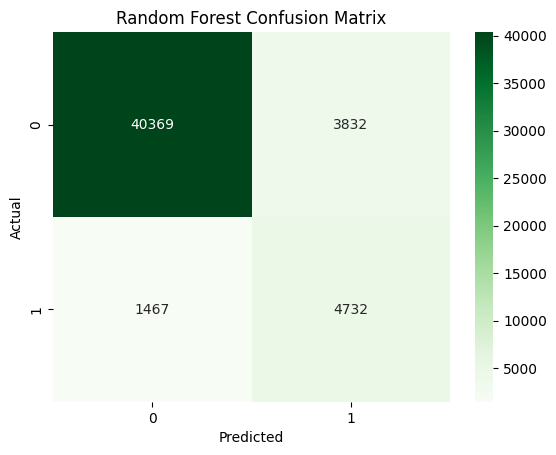

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

Hyperparameter Tuning for Random Forest

Tune RF on three seperate trees and parameters for best possible outcome

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_1 = RandomForestClassifier(
    n_estimators=25,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_2 = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

Train the tuned models

In [29]:
rf_1 = RandomForestClassifier(...)
rf_2 = RandomForestClassifier(...)
rf_3 = RandomForestClassifier(...)

Make Predictions

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_1 = RandomForestClassifier(
    n_estimators=25,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_2 = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_1.fit(X_train_encoded, y_train)
rf_2.fit(X_train_encoded, y_train)
rf_3.fit(X_train_encoded, y_train)

rf1_pred = rf_1.predict(X_test_encoded)
rf2_pred = rf_2.predict(X_test_encoded)
rf3_pred = rf_3.predict(X_test_encoded)

View Results

In [31]:
from sklearn.metrics import classification_report

print("RF 1")
print(classification_report(y_test, rf1_pred))

print("\nRF 2")
print(classification_report(y_test, rf2_pred))

print("\nRF 3")
print(classification_report(y_test, rf3_pred))

RF 1
              precision    recall  f1-score   support

           0       0.91      0.73      0.81     44201
           1       0.20      0.48      0.28      6199

    accuracy                           0.70     50400
   macro avg       0.55      0.60      0.55     50400
weighted avg       0.82      0.70      0.75     50400


RF 2
              precision    recall  f1-score   support

           0       0.93      0.78      0.84     44201
           1       0.26      0.56      0.35      6199

    accuracy                           0.75     50400
   macro avg       0.59      0.67      0.60     50400
weighted avg       0.84      0.75      0.78     50400


RF 3
              precision    recall  f1-score   support

           0       0.94      0.84      0.89     44201
           1       0.36      0.65      0.46      6199

    accuracy                           0.81     50400
   macro avg       0.65      0.74      0.68     50400
weighted avg       0.87      0.81      0.84     50400



Comparison Table

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, model in [
    ("RF 1", rf_1),
    ("RF 2", rf_2),
    ("RF 3", rf_3)
]:

    pred = model.predict(X_test_encoded)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1
0,RF 1,0.700377,0.199338,0.476045,0.281007
1,RF 2,0.748651,0.257734,0.555090,0.352020
2,RF 3,0.814881,0.360061,0.649782,0.463361


Original Scores

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      0.91      0.94     44201
           1       0.55      0.76      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400



Verdict

Several Random Forest configurations were evaluated to investigate the impact of tree depth and ensemble size on model performance. While increasing the depth improved recall and F1-score, none of the tuned models outperformed the original Random Forest model. The original model achieved the highest recall (76%) and F1-score (64%), making it the preferred model for identifying high-risk applicants.

# Final Discussion